# Bayes' Nets: Independence


## Assumptions
- chain rule -> bayes net
  - $P(x_i|x_1...x_{i-1}) = P(x_i|parents(X_i))$
- Often additional conditional independencies
- Other assumptions can be read off the graph.
- Vital for modeling: understand assumptions made when choosing a Bayes net graph.

## Example
- Assume a BN with the following structure:
```
X -> Y -> Z -> W
```

- Direct conditional independences (from chain rule simplifications):

- Factorization frome the chain rule:
  - P(X, Y, Z, W) = P(X) × P(Y | X) × P(Z | Y) × P(W | Z)

- **Z ⊥ X | Y**  
  (Z is independent of X given Y — its parent is Y, so it doesn't need X once Y is known)

- **W ⊥ Y | Z**  
  (W is independent of Y given Z)

- **W ⊥ X | Z**  
  (W is independent of X given Z; this follows because W only depends directly on Z)

- These come straight from the arrows: **each node is independent of its non-descendants given its parents**.

- Note also that X and Z are not neccesarily independent as X can influence Z and Z can influence X via Y





## D-seperation
- Best order to conceptualize:
  - Study independence properties for triple
  - Analyze complex cases in terms of member triples.
  - *D-seperation*: a condition/algorithm for answering such queries (more below)

### Causal Chains
- Low Pressure (x) -> Rain (y) -> Traffic (z)
  - - Thanks to conditional independence, this formula represents the example:
  - $P(x,y,z) = P(x)P(y|x)P(z|y)$
  - This configuartion is called a *causal chain*
- In this example Low Pressure is NOT garanteed to be independent of Traffic
  - In the case where you are given a CPT that convers this (there are others):
    - low pressure causes rain causes traffic.
    - High pressure causes no rain causes no traffic
  - There is NOT independence

- But, the structure above does garantee that X is independent of Z given Y
  - $X \perp Z | Y$
  - This is because of the combination of chain and conditional independence:
    - Traditional conditional probability formula: $P(z|x,y) = \frac{P(x,y,z)}{P(x,y)}$
    - Since X $\perp$ Z|Y, the joint prob as: $P(x,y,z) = P(x) \cdot P(y|x) \cdot P (z|y)$
    - Now we can sub this in for the numerator of $\frac{P(x,y,z)}{P(x,y)}$:
      - $P(z \mid x, y) = \frac{P(x) \cdot P(y \mid x) \cdot P(z \mid y)}{P(x, y)}$
    - To sub out the denominator, we can use the chain rule on P(x,y) to get:
      - $P(x,y) = P(x) \cdot P(y|x)$
    - Now we put it all together and simplify:
      - $P(z \mid x, y) = \frac{P(x) \cdot P(y \mid x) \cdot P(z \mid y)}{P(x) \cdot P(y \mid x)}$
      - $P(z|x,y) = (z|y)$
      - This explicitly means that z and x are completley independent of eachother **given Y.**
    
### Common Cause
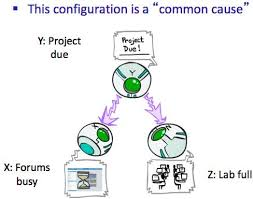
- X is not guaranteed independent of Z as one example set of CPTs could disprove the guarantee
- X and Z are independent given Y because of the same math in the above example and the following rule form way earlier:
  - **Each node is independent of its non-descendants given its parents.**

### Common Effect
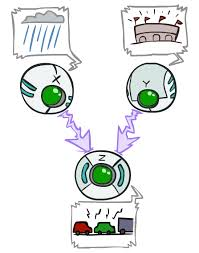
- Two causes of one Effect
- X and Y are guaranteed independent but you must still prove it.
- X and Y are **not** independent given Z.
  - This is because seeing traffic puts rain and the ballgame in competition as explanation.  
  - This is backwards from the previous two cases as **observing an effect activates influence between possible causes.**



### The General Case
- The question: In a given BN, are two variables independent (given evidence)?
  - Solve this by analyzing the graph.
  - Any complex example can be broken into repitions of the 3 canonical cases above

### Reachability
- Steps:
  - Shade all *evidence nodes* - nodes you have observed/are given
  - Disreguard arrows and try to find an one path between the **two** nodes you care about.
    - If this path is not blocked by a shaded node, then the nodes included in that path are **dependent**
    - If all paths between nodes are blocked by the shaded nodes, then the two nodes are **conditionally independent** give the evidence.
- The above steps almost work all of the time, but there is an exception for V structures.
- **unobserved** - not shaded
- **observed** - shaded
- A path is **active** (can move across it) in these cases:
  - Causal chain: A->B->C where B is observed
  - Common Cause: A <- B -> C where B is unobserved
  - Common effect (v-structure): A -> B <- C where B or one of its descendents **is observed**
    - Note: this is opposite
  - All of these paths are active:
    - S -> US -> US
    - US -> US -> S
    - S -> US -> S

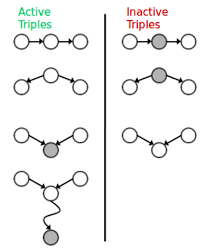

### D-Separation
- $  X_i \perp X_j \mid \{X_{k_1}, \dots, X_{k_n}\}  $
  - "Is $  X_i  $ independent of $  X_j  $ given the set of variables $  \{X_{k_1}, \dots, X_{k_n}\}  $?"
- Check all (undirected) paths between $X_i$ and $X_j$
  - If one or more are active, then conditional independence is not guaranteed
  - If all paths are inactive, then conditional independence is guaranteed
- Example:
  - L ⊥ T' | T - means to shade node T and then analyze the paths


## Structure Implications
- Given the structure, you can run d-separation to build a complete list of conditional independencies in the form: $  X_i \perp X_j \mid \{X_{k_1}, \dots, X_{k_n}\}  $

- The list determines the set of probability distributions that can be represented

### Topology Limits Distributions
- Given some graph topology G, only certain joint distributions can be encoded.
- Adding arcs increases the set of distributions but has several costs.
- *Full conditioning* - no (non-trivial) conditional independences forced by the graph structure.
  - Meaning any distribution can be encoded by the graph.

### Bayes Nets Representation Summary
- These networks compactly encode joint distributions.
- Guaranteed independencies of distributions can be deduced from BN graph structure.
- D-separation gives precise conditional independence guarantees from graph alone
- A Bayes' Network joint distribution may have further conditional independence that is not detectable solely by d-seperation.
  - The actual probability numbers in the CPTs can create extra independencces that the graph does not know about.